# PROJECT-5. Поведенческая аналитика (проведение ad-hoc исследования)

### ОПИСАНИЕ КЕЙСА
Я работаю продуктовым аналитиком в компании-сервисе по доставке продуктов на дом. Сервис доступен как в приложении на iOS, так и на Android. Я настроил фронтовую аналитику в AppMetrica, и в конце квартала маркетинг-менеджер попросил меня проанализировать поведение пользователей, а также оценить эффективность каналов их привлечения.

Данные из AppMetrica за период с 1 января по 31 марта 2020 — только по пользователям, зарегистрированным позднее 1 января 2020.


### Контрольные вопросы:
1. График с событиями по дням и ответ на вопросы: В каком месте маркетинг работает недостаточно хорошо? За счёт чего можно расти?
2. График с распределением трафика (открытие приложения) по группам «Установили в тот же день» и «Остальные».
3. График с динамикой установок приложения по каналам привлечения и ответ на вопрос: С каких платных каналов приходит больше и меньше всего пользователей?
4. Анализ: на каком этапе воронки отваливается большая часть клиентов (отдельно для зарегистрированных и для незарегистрированных пользователей). Сформулировать предложение по оптимизации.
5. Выбор лучшего и худшего каналов по конверсии в первую покупку.
6. Расчёт ROMI для всех каналов.
7. Таблица когорт (в абс. и %) по неделе первого посещения, выбор самой большой и самой активной когорт.
8. Таблица когорт (в абс. и %) по неделе первой покупки, выбор самой активной когорты и анализ динамики активности.
9. Расчёт среднего/медианного чека по когортам (недели первой покупки) в каждую неделю с момента первой покупки, указание диапазонов.


### ОПИСАНИЕ ДАННЫХ 

→ date — дата совершения события
→ event — событие
* app_install — установка приложения
* app_start —  открыть приложения
* registration — зарегистрироваться 
* search — перейти на страницу поиска товаров (каталог)
* open_item — открыть товар
* choose_item — отправить товар в корзину
* tap_basket — перейти в корзину
* purchase — подтверждение покупки
→ gender — пол пользователя
→ os_name —  платформа пользователя
→ city —  город пользователя
→ device_id — идентификатор устройства пользователя
→ utm_source — канал, с которого пришел пользователь
* yandex-direct — Яндекс.Директ
* google_ads — реклама в Google
* vk_ads — реклама в ВК
* instagram_ads — реклама в Instagram
* facebook_ads — реклама в Facebook
* referral — акция «приведи друга»
* Если стоит - (прочерк), то канал не определен или это скачивание приложения напрямую или посещение не с рекламы  
→ purchase_sum —  стоимость покупки (при совершении события ‘purchase’)


##### Обратить внимание!
В выгрузке только уникальные действия пользователей за каждый день.
Можно миновать стадию установки приложения, если оно было установлено ранее.
Можно миновать стадию регистрации, если пользователь был уже залогинен на момент сессии. Однако незарегистрированные пользователи не могут оформить покупку.

## Подготовка и преобразование данных

In [1]:
import pandas as pd
import numpy as np
import datetime as dt

import plotly.express as px
import plotly.graph_objects as go
from plotly.offline import iplot
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
# Выгружаем данные из таблицы и записываем их в переменную df:
df=pd.read_csv('data/SF_case_data.csv')

In [3]:
# Приводим данные колонки 'date' в формат даты:
df['date']=pd.to_datetime(df['date'])

In [4]:
# Посмотрим на таблицу данных с которой будем работать в дальнейшем:
df

,date,event,purchase_sum,os_name,device_id,gender,city,utm_source
0,2020-01-01,app_start,NaN,android,669460,female,Moscow,-
1,2020-01-01,app_start,NaN,ios,833621,male,Moscow,vk_ads
2,2020-01-01,app_start,NaN,android,1579237,male,Saint-Petersburg,referal
3,2020-01-01,app_start,NaN,android,1737182,female,Moscow,facebook_ads
4,2020-01-01,app_start,NaN,ios,4029024,female,Moscow,facebook_ads
...,...,...,...,...,...,...,...,...
2747963,2020-03-31,register,NaN,android,2984778,male,Saint-Petersburg,facebook_ads
2747964,2020-03-31,register,NaN,ios,27301864,male,Moscow,-
2747965,2020-03-31,register,NaN,ios,1294285,female,Saint-Petersburg,google_ads
2747966,2020-03-31,register,NaN,android,3010574,female,Saint-Petersburg,google_ads


### 1: 
##### График с событиями по дням и ответ на вопросы: В каком месте маркетинг работает недостаточно хорошо? За счёт чего можно расти?

In [5]:
# Группируем датафрейм по дате, выводим данные по всем событиям по дням в переменной df_grouped:
df_grouped = df.groupby(['date']).count().reset_index()
df_grouped = df_grouped[['date', 'event']]
df_grouped

,date,event
0,2020-01-01,19781
1,2020-01-02,21640
2,2020-01-03,20861
3,2020-01-04,19152
4,2020-01-05,21716
...,...,...
86,2020-03-27,27736
87,2020-03-28,22741
88,2020-03-29,21001
89,2020-03-30,20306


In [6]:
# Строим график с динамикой событий по дням - переменная fig1:
fig1 = px.line(df_grouped, x=df_grouped['date'], y=df_grouped['event'], title='График с динамикой по всем событиям по дням')
fig1.show()

### 1 - вывод:

##### 1. В каком месте маркетинг работает недостаточно хорошо? 
##### Ответ:
Если рассматривать динамику всех событий, совершённых пользователями в приложении по дням как результат работы маркетинга, то из графика выше видно, что маркетинг особенно проседает в следующие даты:
- с 1 по 8 января; 
- с середины января до 11 февраля; 
- с 15 по 20 февраля; 
- ~ с 23 февраля по 5 марта; 
- с 8 по 16 марта; с 27 по 31 марта. 

##### 2. За счёт чего можно расти?
##### Ответ:
Стоит отметить сезонность и влияние праздничных дней (Новый год, Международный женский день) на динамику событий в приложении, когда люди вероятнее всего больше времени уделяют праздничным мероприятиям и соответственно это сказывается на активности в приложении. Однако можно отметить и непродолжительные всплески активности в предпразничные дни (12-14 февраля, 5-6 марта), которые предположительно происходят по причине хорошей работы маркетинга. На мой взгляд, можно попробовать определить точки потенциального роста в послепраздничные дни, когда активность резко снижается и проводить дополнительные маркетинговые кампании для удержания высокой активности на более продолжительный период.

### 2:
##### График с распределением трафика (открытие приложения) по группам «Установили в тот же день» и «Остальные».

In [7]:
# Определение функции построения графика
def detalized_graphs(data, group_col, date_col, value_col, title):
    fig=px.line(data, x=data[date_col], y=data[value_col], color = group_col, title=title)
    return fig.show()

In [8]:
# Отбор событий установки
installs = df[df['event'] == 'app_install']

# Вычисление даты установки для каждого устройства
df['install_date'] = df['device_id'].map(installs.set_index('device_id')['date'])

# Функция для формирования новой колонки
def new_column(date1, date2, value):
    if date1 == date2:
        return value

df['install_group'] = df.apply(lambda x: new_column(date1=x['date'], date2=x['install_date'], value='Установили в этот же день'), axis=1)
df['install_group'] = df['install_group'].fillna('Остальные')

# Подсчет количества по группам для события 'app_start'
print(df[df['event'] == 'app_start']['install_group'].value_counts())

install_group
Остальные                    594108
Установили в этот же день    154597
Name: count, dtype: int64


In [9]:
# Агрегация данных по дате и группе
dm = df[df['event'] == 'app_start'].groupby(['date', 'install_group']).size().reset_index(name='users')

# Построение графика
detalized_graphs(dm, 'install_group', 'date', 'users', 'Динамика открытий приложения по группам')

#####  Ответим на вопросы:
1. Сколько людей установили приложение 31 марта?
2. Какая доля открытий приложения 14 февраля пришлась на пользователей, у которых приложение уже было установлено

In [10]:
# Фильтр пользователей, установивших приложение 31 марта
install_events = df[(df['event'] == 'app_install') & (df['install_date'] == '2020-03-31')]

# Подсчет уникальных пользователей
unique_users = install_events['device_id'].nunique()
print(unique_users)

968


In [11]:
# Запуски приложения 14 февраля 2020
starts_feb_14 = df[(df['event'] == 'app_start') & (df['date'] == '2020-02-14')]

# Пользователи с установкой до 14 февраля
installed_before_feb_14 = starts_feb_14[starts_feb_14['install_date']<='2020-02-14']

# Количество запусков 14 февраля среди таких пользователей
existing_users_starts = installed_before_feb_14.shape[0]

# Общее количество запусков 14 февраля
total_starts = starts_feb_14.shape[0]

# Доля в процентах
share = round((existing_users_starts / total_starts) * 100) if total_starts != 0 else 0

print(f'Доля запусков 14 февраля от пользователей с установкой ранее: {share}%')


Доля запусков 14 февраля от пользователей с установкой ранее: 81%


### 2 - вывод:

На графике выше видно как распределяется трафик открытий приложения пользователями: динамика открытий приложений у пользователей из группы "Установили в тот же день" значительно выше, чем у группы "Остальные". Также, наблюдается прямая сильная корреляция между данными группами: сильный всплеск активности приходится на определённые даты (предпразничные, праздничные, послепразничные дни), поэтому данные колебания можно отнести либо к сезонности, когда пользователи больше времени проводят в приложении, либо к маркетинговым/рекламным кампаниям, привязанным к соответствующим сезонным датам.

### 3: 
##### График с динамикой установок приложения по каналам привлечения и ответ на вопрос: С каких платных каналов приходит больше и меньше всего пользователей?

In [12]:
# Группируем по признаку установки, что бы вычислить долю инсталов:
group1 = dm[dm['install_group'] == 'Остальные']
group2 = dm[dm['install_group'] != 'Остальные']
stat = group1.merge(group2, how = 'left', on = 'date')
stat['Доля трафика с инсталлов, %'] = stat['users_y']/(stat['users_y'] +stat['users_x'])
stat['gr'] = 'Трафик с инсталлов'
stat.sort_values('Доля трафика с инсталлов, %', ascending = True).head(3)

,date,install_group_x,users_x,install_group_y,users_y,"Доля трафика с инсталлов, %",gr
75,2020-03-16,Остальные,5786,Установили в этот же день,360,0.058575,Трафик с инсталлов
76,2020-03-17,Остальные,6111,Установили в этот же день,431,0.065882,Трафик с инсталлов
64,2020-03-05,Остальные,5759,Установили в этот же день,411,0.066613,Трафик с инсталлов


In [13]:
detalized_graphs(stat, 'gr', 'date', 'Доля трафика с инсталлов, %','Доля трафика с инсталлов, %')

In [14]:
# Отобразим события установки приложений (app_install), сгруппированных по каналу, с которого пришел пользователь (utm_source):

utm_1 = df[df['event'] == 'app_install'].groupby('utm_source').size().reset_index(name = 'users')
utm_1.sort_values('users', ascending=False)

,utm_source,users
0,-,32460
6,yandex-direct,29368
2,google_ads,26286
5,vk_ads,23189
3,instagram_ads,20096
1,facebook_ads,13916
4,referal,9282


In [15]:
# Отобразим на графике динамику установок приложения по каналам привлечения:
df1 = df[df['event'] == 'app_install'].sort_values('date').drop_duplicates('device_id').groupby(['date','utm_source'])\
    .size().reset_index(name = 'users')
detalized_graphs(df1, 'utm_source', 'date', 'users', 'Динамика установок приложения по каналам привлечения')

###  3 - вывод:
##### С каких платных каналов приходит больше и меньше всего пользователей?

Из таблицы выше видим, что больше всего пользователей пришло с каналов: 
- yandex-direct: 29368, 
- google_ads: 26286 
- и vk_ads: 23189
меньше всего пользователей пришло с каналов: 
- referal - 9282, 
- facebook_ads - 13916, 
- instagram_ads - 20096


Заметка: в данном примере, реферальная программа (referal) рассматривается как канал привлечения.

### 4:
##### Анализ: на каком этапе воронки отваливается большая часть клиентов (отдельно для зарегистрированных и для незарегистрированных пользователей). Сформулируйте предложение по оптимизации.


Для этого создадим новые переменные с данными пользователей по событиям: регистрации, поиска... 
Чтобы выделить группы тех, кому нужно и не нужно регистрироваться, добавим столбец с датой регистрации в первоначальный датафрейм (df). Добавим столбец registered для определения групп зарегистрированных и незарегистрированных пользователей: если дата регистрации меньше даты совершения события, то пользователь уже зарегистрирован; если дата регистрации больше или равна дате совершения события, то пользователь ещё не зарегистрирован.

In [16]:
# Добавим переменную first_start для отображения всех событий с первым открытием приложения:
first_start = df[df.event == 'app_start'].drop_duplicates('device_id').sort_values('device_id')
# Сгруппируем по каналам и выведем количество первых открытий по каналам:
first_start = first_start[first_start['event'] == 'app_start'].groupby(['utm_source']).size().reset_index(name='users')
first_start.sort_values('users', ascending=False)

,utm_source,users
0,-,41456
6,yandex-direct,34441
2,google_ads,31437
5,vk_ads,27905
3,instagram_ads,24818
1,facebook_ads,18844
4,referal,11983


In [17]:
# Создаём новую переменную registered, в которую включаем всех зерегистрированных пользователей:
registered = df[df['event'] == 'register'].sort_values('date')
# Добавим в df дополнительный столбец по индексу device_id с датой регистрации
df['first_registration'] = df['device_id'].map(registered.set_index('device_id')['date'])
# Добавляем новый столбец, в котором присваиваем всем зерегистрированным пользователям значение 'yes':
registered['registered'] = 'yes'
# Добавим в df дополнительный столбец по индексу device_id , в котором присваиваем 
# всем зерегистрированным пользователям значение 'yes' а не зерегистрированным пользователям значение 'no':
df['registered'] = np.where(df['date'] > df['first_registration'], 'yes', 'no')


#df['registered'] = df['device_id'].map(registered.set_index('device_id')['registered'])
#df['registered'] = df['registered'].fillna('no')
df

,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,install_date,install_group,first_registration,registered
0,2020-01-01,app_start,NaN,android,669460,female,Moscow,-,2020-01-01,Установили в этот же день,2020-01-07,no
1,2020-01-01,app_start,NaN,ios,833621,male,Moscow,vk_ads,2020-01-01,Установили в этот же день,2020-01-01,no
2,2020-01-01,app_start,NaN,android,1579237,male,Saint-Petersburg,referal,NaT,Остальные,2020-01-01,no
3,2020-01-01,app_start,NaN,android,1737182,female,Moscow,facebook_ads,2020-01-01,Установили в этот же день,2020-01-01,no
4,2020-01-01,app_start,NaN,ios,4029024,female,Moscow,facebook_ads,2020-01-01,Установили в этот же день,NaT,no
...,...,...,...,...,...,...,...,...,...,...,...,...
2747963,2020-03-31,register,NaN,android,2984778,male,Saint-Petersburg,facebook_ads,2020-03-28,Остальные,2020-03-31,no
2747964,2020-03-31,register,NaN,ios,27301864,male,Moscow,-,2020-03-31,Установили в этот же день,2020-03-31,no
2747965,2020-03-31,register,NaN,ios,1294285,female,Saint-Petersburg,google_ads,2020-03-31,Установили в этот же день,2020-03-31,no
2747966,2020-03-31,register,NaN,android,3010574,female,Saint-Petersburg,google_ads,2020-03-06,Остальные,2020-03-31,no


In [18]:
# Скопируем наш DataFrame, что бы не потерять данные:
df2=df

In [19]:
# Оценим, какие уникальные события есть в колонке event
df.event.unique()

array(['app_start', 'choose_item', 'purchase', 'search', 'tap_basket',
       'app_install', 'register'], dtype=object)

In [20]:
# Выводим отдельные события, в разрезе групп зарегистрированных и незарегистрированных пользователей:
display(df2[df2['event'] == 'app_install'].groupby('registered').count())
display(df2[df2['event'] == 'app_start'].groupby('registered').count())
display(df2[df2['event'] == 'registration'].groupby('registered').count())
display(df2[df2['event'] == 'search'].groupby('registered').count())
display(df2[df2['event'] == 'open_item'].groupby('registered').count())
display(df2[df2['event'] == 'choose_item'].groupby('registered').count())
display(df2[df2['event'] == 'tap_basket'].groupby('registered').count())
display(df2[df2['event'] == 'purchase'].groupby('registered').count())

,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,install_date,install_group,first_registration
registered,,,,,,,,,,,
no,154597,154597,0,154597,154597,154597,154597,154597,154597,154597,63526


,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,install_date,install_group,first_registration
registered,,,,,,,,,,,
no,307219,307219,0,307219,307219,307219,307219,307219,249033,307219,153236
yes,441486,441486,0,441486,441486,441486,441486,441486,359668,441486,441486


,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,install_date,install_group,first_registration
registered,,,,,,,,,,,


,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,install_date,install_group,first_registration
registered,,,,,,,,,,,
no,291538,291538,0,291538,291538,291538,291538,291538,236328,291538,148170
yes,417101,417101,0,417101,417101,417101,417101,417101,339712,417101,417101


,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,install_date,install_group,first_registration
registered,,,,,,,,,,,


,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,install_date,install_group,first_registration
registered,,,,,,,,,,,
no,224196,224196,0,224196,224196,224196,224196,224196,181586,224196,125994
yes,314473,314473,0,314473,314473,314473,314473,314473,256218,314473,314473


,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,install_date,install_group,first_registration
registered,,,,,,,,,,,
no,160409,160409,0,160409,160409,160409,160409,160409,130022,160409,105031
yes,217256,217256,0,217256,217256,217256,217256,217256,177108,217256,217256


,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,install_date,install_group,first_registration
registered,,,,,,,,,,,
no,67753,67753,67753,67753,67753,67753,67753,67753,54966,67753,67753
yes,73630,73630,73630,73630,73630,73630,73630,73630,60259,73630,73630


### 4.1 - зарегистрированные пользователи:

In [21]:
# Скопируем датафрейм df2 с зарегистрированными пользователями в новый датафрейм reg:
reg = df2[df2['registered'] == 'yes']


In [22]:
# Формируем таблицу кросс-табуляции с частотой зарегистрированных пользователей 
# в разрезе событий и каналов привлечения по порядку шагов воронки:
funnel_reg = pd.crosstab(reg.utm_source, reg.event, values = reg.device_id, aggfunc = pd.Series.nunique)
new_order = ['app_start', 'search', 'choose_item','tap_basket', 'purchase']
funnel_reg = funnel_reg[new_order]
funnel_reg


event,app_start,search,choose_item,tap_basket,purchase
utm_source,,,,,
-,9482,9355,8728,7850,5492
facebook_ads,5606,5527,5154,4694,3333
google_ads,5399,5335,4948,4438,3121
instagram_ads,5686,5618,5288,4842,3548
referal,3647,3610,3417,3155,2382
vk_ads,6011,5958,5636,5196,3950
yandex-direct,5396,5304,4928,4464,3099


In [23]:
# Добавим строку с общим количеством зарегистрированных пользователей: 
total_reg=funnel_reg.sum()
total_reg=total_reg.to_frame(name='Total')
total_reg=total_reg.transpose()
total_reg

funnel_reg=pd.concat([funnel_reg,total_reg])

funnel_reg

event,app_start,search,choose_item,tap_basket,purchase
-,9482,9355,8728,7850,5492
facebook_ads,5606,5527,5154,4694,3333
google_ads,5399,5335,4948,4438,3121
instagram_ads,5686,5618,5288,4842,3548
referal,3647,3610,3417,3155,2382
vk_ads,6011,5958,5636,5196,3950
yandex-direct,5396,5304,4928,4464,3099
Total,41227,40707,38099,34639,24925


In [24]:
# Добавляем столбцы с событиями, в которых рассчитываем конверсию на каждом шаге воронки:
funnel_reg['search/app_start'] = funnel_reg['search']*100/funnel_reg['app_start']
funnel_reg['choose_item/search'] = funnel_reg['choose_item']*100/funnel_reg['search']
funnel_reg['tap_basket/choose_item'] = funnel_reg['tap_basket']*100/funnel_reg['choose_item']
funnel_reg['purchase/tap_basket'] = funnel_reg['purchase']*100/funnel_reg['tap_basket']
funnel_reg

event,app_start,search,choose_item,tap_basket,purchase,search/app_start,choose_item/search,tap_basket/choose_item,purchase/tap_basket
-,9482,9355,8728,7850,5492,98.660620,93.297702,89.940422,69.961783
facebook_ads,5606,5527,5154,4694,3333,98.590796,93.251312,91.074893,71.005539
google_ads,5399,5335,4948,4438,3121,98.814595,92.746017,89.692805,70.324470
instagram_ads,5686,5618,5288,4842,3548,98.804080,94.126023,91.565809,73.275506
referal,3647,3610,3417,3155,2382,98.985468,94.653740,92.332455,75.499208
vk_ads,6011,5958,5636,5196,3950,99.118283,94.595502,92.193045,76.020015
yandex-direct,5396,5304,4928,4464,3099,98.295033,92.911011,90.584416,69.422043
Total,41227,40707,38099,34639,24925,98.738691,93.593239,90.918397,71.956465


### 4.1 - вывод:
Таким образом, большая часть зарегистрированных пользователей отваливается на этапе покупки (purchase/tap_basket). 

- На этапе добавления в корзину, всего -  34639; 
- на этапе покупки, всего -  24925;
* Конверсия уникальных пользователей из этапа добавления в корзину в покупку: 72%. 

Можно попробовать оптимизировать сам процесс покупки, т.е. на шаге добавления товара в корзину, добавить опцию автоматической покупки или другое альтернативное решение. 

### 4.2 - незарегистрированные пользователи:

In [25]:
# Скопируем датафрейм df2 с незарегистрированными пользователями в новый датафрейм no_reg:
not_reg = df2[df2['registered'] == 'no']

In [26]:
# Формируем таблицу кросс-табуляции с частотой незарегистрированных пользователей 
# в разрезе событий и каналов привлечения по порядку шагов воронки:
funnel_not_reg = pd.crosstab(not_reg.utm_source, not_reg.event, values = not_reg.device_id, aggfunc = pd.Series.nunique)
new_order = ['app_start', 'search', 'choose_item','tap_basket', 'app_install', 'register', 'purchase']
funnel_not_reg = funnel_not_reg[new_order]
funnel_not_reg

event,app_start,search,choose_item,tap_basket,app_install,register,purchase
utm_source,,,,,,,
-,48670,46742,38026,29223,32460,16527,14073
facebook_ads,23780,22822,18713,14592,13916,8672,7506
google_ads,35778,34217,27416,20765,26286,11405,9777
instagram_ads,29237,28017,22858,17881,20096,10750,9394
referal,14866,14316,11880,9518,9282,6193,5503
vk_ads,32353,31010,25422,20014,23189,12421,10919
yandex-direct,38578,36933,29591,22417,29368,12342,10581


In [27]:
# Добавим строку с общим количеством незарегистрированных пользователей: 
total_not_reg=funnel_not_reg.sum()
total_not_reg=total_not_reg.to_frame(name='Total')
total_not_reg=total_not_reg.transpose()
total_not_reg

funnel_not_reg=pd.concat([funnel_not_reg,total_not_reg])

funnel_not_reg

event,app_start,search,choose_item,tap_basket,app_install,register,purchase
-,48670,46742,38026,29223,32460,16527,14073
facebook_ads,23780,22822,18713,14592,13916,8672,7506
google_ads,35778,34217,27416,20765,26286,11405,9777
instagram_ads,29237,28017,22858,17881,20096,10750,9394
referal,14866,14316,11880,9518,9282,6193,5503
vk_ads,32353,31010,25422,20014,23189,12421,10919
yandex-direct,38578,36933,29591,22417,29368,12342,10581
Total,223262,214057,173906,134410,154597,78310,67753


In [28]:
# Шаги воронки: app_install > app_start > search > open_item > choose_item > tap_basket > registration > purchase

# Добавляем столбцы с событиями, в которых рассчитываем конверсию на каждом шаге воронки:
funnel_not_reg['sear/app_st'] = funnel_not_reg['search']*100/funnel_not_reg['app_start']
funnel_not_reg['choose_i/sear'] = funnel_not_reg['choose_item']*100/funnel_not_reg['search']
funnel_not_reg['tap_b/choose_i'] = funnel_not_reg['tap_basket']*100/funnel_not_reg['choose_item']
funnel_not_reg['reg/tap_b'] = funnel_not_reg['register']*100/funnel_not_reg['tap_basket']
funnel_not_reg['pur/reg'] = funnel_not_reg['purchase']*100/funnel_not_reg['register']
funnel_not_reg

event,app_start,search,choose_item,tap_basket,app_install,register,purchase,sear/app_st,choose_i/sear,tap_b/choose_i,reg/tap_b,pur/reg
-,48670,46742,38026,29223,32460,16527,14073,96.038627,81.352959,76.850050,56.554769,85.151570
facebook_ads,23780,22822,18713,14592,13916,8672,7506,95.971405,81.995443,77.977876,59.429825,86.554428
google_ads,35778,34217,27416,20765,26286,11405,9777,95.636984,80.123915,75.740444,54.924151,85.725559
instagram_ads,29237,28017,22858,17881,20096,10750,9394,95.827205,81.586180,78.226442,60.119680,87.386047
referal,14866,14316,11880,9518,9282,6193,5503,96.300283,82.984074,80.117845,65.066190,88.858389
vk_ads,32353,31010,25422,20014,23189,12421,10919,95.848917,81.980006,78.727087,62.061557,87.907576
yandex-direct,38578,36933,29591,22417,29368,12342,10581,95.735912,80.120759,75.756142,55.056430,85.731648
Total,223262,214057,173906,134410,154597,78310,67753,95.877041,81.242847,77.288880,58.262034,86.518963


### 4.2 - вывод:

Большая часть незарегистрированных пользователей отваливается на этапе регистрации (reg/tap_b). 

- На этапе регистрации, всего - 78310;
- На этапе установки приложения - 154597;
- На этапе добавления в корзину, всего - 134410; 
- на этапе покупки, всего - 67753;
** Конверсия уникальных пользователей из этапа добавления в корзину в покупку: 58%. 

Для незарегистрированных пользователей, можно оптимизировать сам процесс регистрации, т.к. на шаге регистрации (78310 уникальных пользователей) отваливаются почти половина пользователей от установивших приложение - 154597. На этапе из добавления товара в корзину в покупку, стоит подумать над возможностью добавления опции автоматической покупки или другого альтернативного решения для повышения конверсии на данном этапе, с текущего показателя 58% до как минимум 72% .


### 5: 
##### Выбор лучшего и худшего каналов по конверсии в первую покупку.

In [29]:
# Создаём новую переменную, в которую включаем всех пользователей, открывших приложение:
df2['date'] = pd.to_datetime(df['date'])
first_opening = df2[df2['event'] == 'app_start'].sort_values('date').drop_duplicates('device_id').groupby('utm_source').\
                size().reset_index(name = 'users')
first_opening

,utm_source,users
0,-,41456
1,facebook_ads,18844
2,google_ads,31437
3,instagram_ads,24818
4,referal,11983
5,vk_ads,27905
6,yandex-direct,34441


In [30]:
# Создаём новую переменную, в которую включаем всех пользователей, совершивших первую покупку:
first_purchase = df2.loc[df['event'] == 'purchase'].sort_values('date').drop_duplicates('device_id').groupby('utm_source').\
                size().reset_index(name = 'users')
first_purchase

,utm_source,users
0,-,14786
1,facebook_ads,7903
2,google_ads,10167
3,instagram_ads,9820
4,referal,5803
5,vk_ads,11460
6,yandex-direct,10936


In [31]:
# Объединяем полученные датафреймы:
stat = first_opening.merge(first_purchase, how = 'left', on = 'utm_source')
# stat = stat.rename(columns = {'users_x': 'first_opening', 'users_y': 'first_purchase'})
stat['CR_to_first_purchase'] = stat['users_y']*100 / stat['users_x']
# Сортируем от наибольшей к наименьшей конверсии в покупку:
stat.sort_values('CR_to_first_purchase', ascending = False)

,utm_source,users_x,users_y,CR_to_first_purchase
4,referal,11983,5803,48.426938
1,facebook_ads,18844,7903,41.939079
5,vk_ads,27905,11460,41.067909
3,instagram_ads,24818,9820,39.568055
0,-,41456,14786,35.666731
2,google_ads,31437,10167,32.340872
6,yandex-direct,34441,10936,31.752853


### 5 - вывод:

Таким образом, наибольшую конверсию в покупку показывает реферальная программа (referal) - 48.43%, а наименьшую конверсию в покупку показывает канал привлечения yandex-direct - 31.75%. Соответственно, лучший канал привлечения - это referal, а худший канал привлечения - это yandex-direct.

### 6: 
##### Расчёт ROMI для всех каналов.


Определение:
ROMI - Return On Marketing Investment (Рентабельность Инвестиций В Маркетинг или Коэффициент Возврата Маркетинговых Инвестиций)

Формула:
ROMI = ((Доходы от Маркетинга - Расходы на маркетинг) / Расходы на маркетинг) * 100%


Данные по затратам на рекламу в Q1:
    Яндекс	    10 491 707 руб.
    Гугл	    10 534 878 руб.
    Фейсбук	     8 590 498 руб.
    Инстаграм	 8 561 626 руб.
    ВК	         9 553 531 руб.    

Расходы на реферальную программу: если пользователь приведет друга и последний совершит первую покупку, то оба получат по 100 рублей.


Заметка: затраты на рекламу учитываются за 1 квартал рассматриваемого периода.

In [32]:
# Найдем медианный первый чек по каналам привлечения:
first_purchase_median = df2.loc[df['event'] == 'purchase'].sort_values('date').drop_duplicates('device_id')\
    .groupby('utm_source')['purchase_sum'].median().reset_index(name = 'median')
first_purchase_median 


,utm_source,median
0,-,398.5
1,facebook_ads,389.0
2,google_ads,390.5
3,instagram_ads,393.5
4,referal,395.5
5,vk_ads,393.0
6,yandex-direct,392.5


In [33]:
# Рассчитываем доход по каждому каналу привлечения:
df2[df2.event == 'purchase'].groupby('utm_source')['purchase_sum'].sum()

utm_source
-                21449749.5
facebook_ads     12249901.0
google_ads       12868276.0
instagram_ads    14546969.0
referal           8837044.5
vk_ads           16389652.5
yandex-direct    13915368.0
Name: purchase_sum, dtype: float64

In [34]:
# Рассчитываем и выводим ROMI по каждому каналу привлечения, в %:
print('Яндекс:    {:.4}%'.format((13915368/10491707-1)*100))
print('Гугл:      {:.4}%'.format((12868276/10534878-1)*100))
print('Фейсбук:   {:.4}%'.format((12249901/8590498-1)*100))
print('Инстаграм: {:.4}%'.format((14546969/8561626-1)*100))
print('ВК:        {:.4}%'.format((16389652.5/9553531-1)*100))

Яндекс:    32.63%
Гугл:      22.15%
Фейсбук:   42.6%
Инстаграм: 69.91%
ВК:        71.56%


In [35]:
# Выводим количество уникальных пользователей по всем каналам, чтобы отдельно рассчитать расходы по реферальной программе:
df2[df2.event == 'purchase'].drop_duplicates('device_id')['utm_source'].value_counts()

utm_source
-                14786
vk_ads           11460
yandex-direct    10936
google_ads       10167
instagram_ads     9820
facebook_ads      7903
referal           5803
Name: count, dtype: int64

In [36]:
# Определяем доход по реферальной программе:
referal_revenue = 8837044.5
# Определяем 5874 пользователей по реферальной программе: рассчитываем расходы по программе за рассматриваемый период:
referal_cost = 5874*(2*100)

# Рассчитываем ROI по реферальной программе:
referal_roi = (referal_revenue/referal_cost-1)*100
referal_roi = round(referal_roi, 2)
referal_roi

652.22

### 6 - вывод:

Из рекламных каналов привлечения (кроме реферальной программы), самый высокий ROMI у ВК (vk_ads) - 71.56%, а самый самый низкий ROMI у Гугл (google_ads) - 22.15%. 
Самая выгодная опция — реферальная программа, которая за 3 месяца привлекла 5874 пользователей и принесла доход 8837044.5 рублей, а расходы составили всего 1174800 рублей (5874*(2*100)). Таким образом, ROI по реферальной программе составил 652.22% - это самая выгодная опция.

### 7: 
##### Таблица когорт (в абс. и %) по неделе первого посещения, выбор самой большой и самой активной когорт.



In [37]:
# Создаём переменную с данными пользователей, открывавших приложения - избавляемся от дубликатов по device_id:
entrances = df2[df2.event == 'app_start'].sort_values('date').drop_duplicates('device_id')
entrances

,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,install_date,install_group,first_registration,registered
0,2020-01-01,app_start,NaN,android,669460,female,Moscow,-,2020-01-01,Установили в этот же день,2020-01-07,no
2955,2020-01-01,app_start,NaN,android,26774527,female,Moscow,yandex-direct,2020-01-01,Установили в этот же день,2020-03-25,no
2956,2020-01-01,app_start,NaN,android,28303290,male,Saint-Petersburg,-,2020-01-01,Установили в этот же день,2020-01-06,no
2957,2020-01-01,app_start,NaN,android,28472833,male,Saint-Petersburg,-,2020-01-01,Установили в этот же день,NaT,no
2958,2020-01-01,app_start,NaN,android,31632652,female,Moscow,facebook_ads,2020-01-01,Установили в этот же день,NaT,no
...,...,...,...,...,...,...,...,...,...,...,...,...
2499255,2020-03-31,app_start,NaN,android,33686588,female,Moscow,google_ads,2020-03-31,Установили в этот же день,NaT,no
2499253,2020-03-31,app_start,NaN,android,32732749,female,Moscow,yandex-direct,2020-03-31,Установили в этот же день,NaT,no
2499252,2020-03-31,app_start,NaN,ios,24329615,male,Moscow,-,2020-03-31,Установили в этот же день,2020-03-31,no
2499251,2020-03-31,app_start,NaN,ios,21705895,male,Saint-Petersburg,yandex-direct,2020-03-31,Установили в этот же день,NaT,no


In [38]:
# Добавляем новый столбец с датами открытия приложения - первого входа уникальными пользователями, в датафрейм df2:
df2['first_entrance'] = df2['device_id'].map(entrances.set_index('device_id')['date'])
df2

,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,install_date,install_group,first_registration,registered,first_entrance
0,2020-01-01,app_start,NaN,android,669460,female,Moscow,-,2020-01-01,Установили в этот же день,2020-01-07,no,2020-01-01
1,2020-01-01,app_start,NaN,ios,833621,male,Moscow,vk_ads,2020-01-01,Установили в этот же день,2020-01-01,no,2020-01-01
2,2020-01-01,app_start,NaN,android,1579237,male,Saint-Petersburg,referal,NaT,Остальные,2020-01-01,no,2020-01-01
3,2020-01-01,app_start,NaN,android,1737182,female,Moscow,facebook_ads,2020-01-01,Установили в этот же день,2020-01-01,no,2020-01-01
4,2020-01-01,app_start,NaN,ios,4029024,female,Moscow,facebook_ads,2020-01-01,Установили в этот же день,NaT,no,2020-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2747963,2020-03-31,register,NaN,android,2984778,male,Saint-Petersburg,facebook_ads,2020-03-28,Остальные,2020-03-31,no,2020-03-28
2747964,2020-03-31,register,NaN,ios,27301864,male,Moscow,-,2020-03-31,Установили в этот же день,2020-03-31,no,2020-03-31
2747965,2020-03-31,register,NaN,ios,1294285,female,Saint-Petersburg,google_ads,2020-03-31,Установили в этот же день,2020-03-31,no,2020-03-31
2747966,2020-03-31,register,NaN,android,3010574,female,Saint-Petersburg,google_ads,2020-03-06,Остальные,2020-03-31,no,2020-03-06


In [39]:
# Добавляем новый столбец с датами открытия приложения - первого входа по недельной когорте:
df2['first_entrance_cohort'] = df2['first_entrance'].apply(lambda x: x + dt.timedelta(days = -x.weekday(), weeks=0))
df2

,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,install_date,install_group,first_registration,registered,first_entrance,first_entrance_cohort
0,2020-01-01,app_start,NaN,android,669460,female,Moscow,-,2020-01-01,Установили в этот же день,2020-01-07,no,2020-01-01,2019-12-30
1,2020-01-01,app_start,NaN,ios,833621,male,Moscow,vk_ads,2020-01-01,Установили в этот же день,2020-01-01,no,2020-01-01,2019-12-30
2,2020-01-01,app_start,NaN,android,1579237,male,Saint-Petersburg,referal,NaT,Остальные,2020-01-01,no,2020-01-01,2019-12-30
3,2020-01-01,app_start,NaN,android,1737182,female,Moscow,facebook_ads,2020-01-01,Установили в этот же день,2020-01-01,no,2020-01-01,2019-12-30
4,2020-01-01,app_start,NaN,ios,4029024,female,Moscow,facebook_ads,2020-01-01,Установили в этот же день,NaT,no,2020-01-01,2019-12-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2747963,2020-03-31,register,NaN,android,2984778,male,Saint-Petersburg,facebook_ads,2020-03-28,Остальные,2020-03-31,no,2020-03-28,2020-03-23
2747964,2020-03-31,register,NaN,ios,27301864,male,Moscow,-,2020-03-31,Установили в этот же день,2020-03-31,no,2020-03-31,2020-03-30
2747965,2020-03-31,register,NaN,ios,1294285,female,Saint-Petersburg,google_ads,2020-03-31,Установили в этот же день,2020-03-31,no,2020-03-31,2020-03-30
2747966,2020-03-31,register,NaN,android,3010574,female,Saint-Petersburg,google_ads,2020-03-06,Остальные,2020-03-31,no,2020-03-06,2020-03-02


In [40]:
# Добавляем переменную, в которой считаем количество недельных когорт = дата события - дата первого входа по недельной когорте:
df2['n_week'] = df2['date'] - df2['first_entrance_cohort']
df2['n_week'] = df2['n_week'].apply(lambda x: x.days // 7)
df2

,date,event,purchase_sum,os_name,device_id,gender,city,utm_source,install_date,install_group,first_registration,registered,first_entrance,first_entrance_cohort,n_week
0,2020-01-01,app_start,NaN,android,669460,female,Moscow,-,2020-01-01,Установили в этот же день,2020-01-07,no,2020-01-01,2019-12-30,0
1,2020-01-01,app_start,NaN,ios,833621,male,Moscow,vk_ads,2020-01-01,Установили в этот же день,2020-01-01,no,2020-01-01,2019-12-30,0
2,2020-01-01,app_start,NaN,android,1579237,male,Saint-Petersburg,referal,NaT,Остальные,2020-01-01,no,2020-01-01,2019-12-30,0
3,2020-01-01,app_start,NaN,android,1737182,female,Moscow,facebook_ads,2020-01-01,Установили в этот же день,2020-01-01,no,2020-01-01,2019-12-30,0
4,2020-01-01,app_start,NaN,ios,4029024,female,Moscow,facebook_ads,2020-01-01,Установили в этот же день,NaT,no,2020-01-01,2019-12-30,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2747963,2020-03-31,register,NaN,android,2984778,male,Saint-Petersburg,facebook_ads,2020-03-28,Остальные,2020-03-31,no,2020-03-28,2020-03-23,1
2747964,2020-03-31,register,NaN,ios,27301864,male,Moscow,-,2020-03-31,Установили в этот же день,2020-03-31,no,2020-03-31,2020-03-30,0
2747965,2020-03-31,register,NaN,ios,1294285,female,Saint-Petersburg,google_ads,2020-03-31,Установили в этот же день,2020-03-31,no,2020-03-31,2020-03-30,0
2747966,2020-03-31,register,NaN,android,3010574,female,Saint-Petersburg,google_ads,2020-03-06,Остальные,2020-03-31,no,2020-03-06,2020-03-02,4


In [41]:
df2['first_entrance_cohort'] = df2['first_entrance_cohort'].apply(lambda x: str(x)[:10])

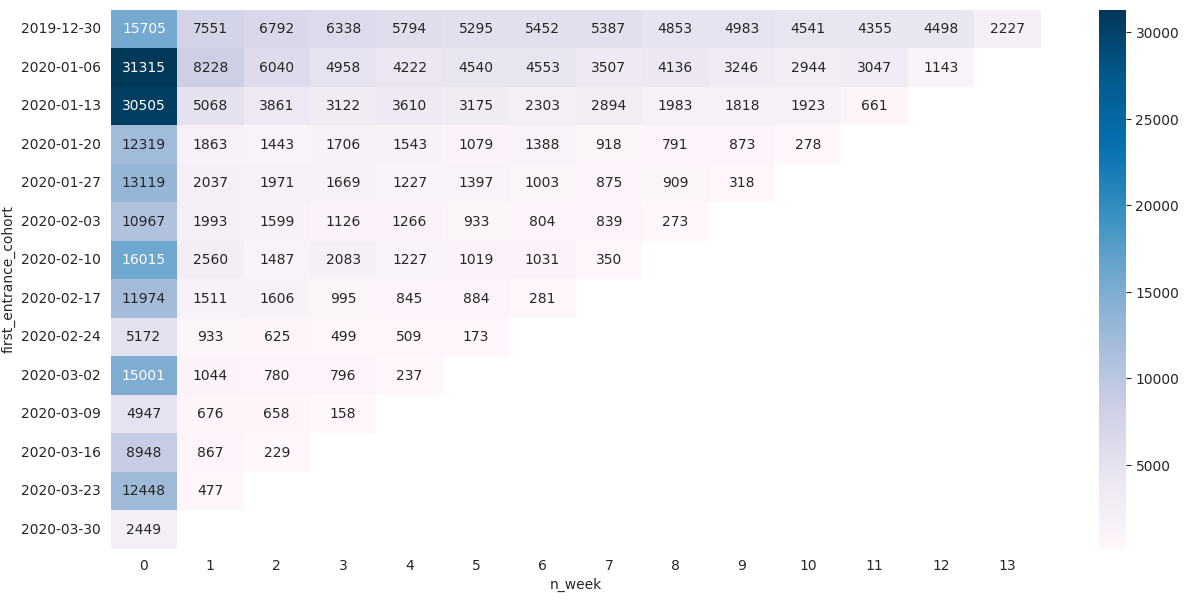

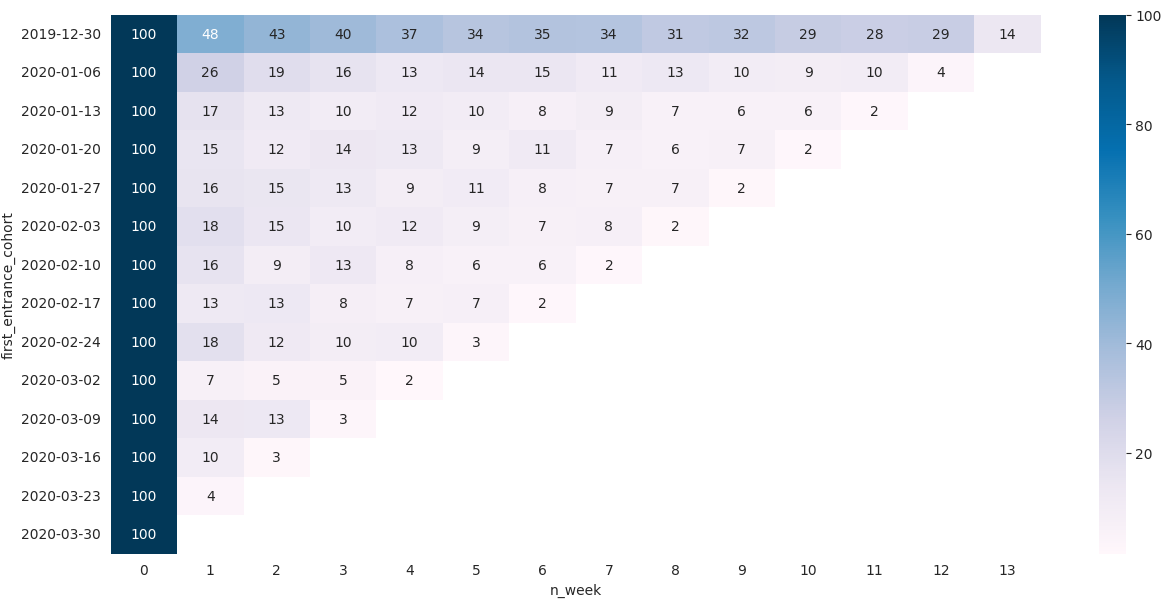

In [42]:
# Визуализируем датафрейм df2 с индексом первого входа по недельной когорте, столбцами: n_week, и значениями: device_id:
viz = df2.pivot_table(
            index = 'first_entrance_cohort',
            columns = 'n_week',
            values = 'device_id',
            aggfunc = pd.Series.nunique)

with sns.axes_style('white'):
    f, ax = plt.subplots(figsize = (15, 7))
    ax = sns.heatmap(viz, annot = True, fmt = '.0f', cmap = 'PuBu');

viz = viz.apply(lambda x: x*100/viz[0])
with sns.axes_style('white'):
    f, ax = plt.subplots(figsize = (15, 7))
    ax = sns.heatmap(viz, annot = True, fmt = '.0f', cmap = 'PuBu');

### 7 - вывод:

На графиках выше видно, что первая когорта (2019-12-30) является самой большой и самой активной, т.к. её выживаемость сравнительно больше, чем у других: начиная с 3-ей по 14-ую недели (n_week: с 2 по 13) - это 12 недель подряд, количество активных пользователей данной когорты превышает количество активных пользователей в других когортах. 
На втором графике, показатели активности пользователей по всем когортам в 1-ой недели (n_week = 0) используются как базовые - 100%, а показатели активности пользователей всех остальных недель делятся на показатели базовой - таким образом, лучше визуализирована активность/выживаемость каждой когорты.


Заметка: при построении данных недельных когорт, точкой отсчёта является неделя первого посещения.

### 8: 
##### Таблица когорт (в абс. и %) по неделе первой покупки, выбор самой активной когорты и анализ динамики активности.


In [43]:
# Создаём переменную с данными пользователей, сделавших покупки - избавляемся от дубликатов по device_id:
purchases = df2[df2.event == 'purchase'].sort_values('date').drop_duplicates('device_id')
# Добавляем столбец с данными первой покупки:
df2['first_purchase'] = df2['device_id'].map(purchases.set_index('device_id')['date'])
# Добавляем столбец с временем первой покупки:
#df2['first_purchase'] = pd.to_datetime(df2['first_purchase'], format = '%Y-%m-%d')
# Создаём новый датафрейм с данными пользователей, имеющих не пустые значения даты первой покупки:
df3 = df2[-df2['first_purchase'].isna()]
df3['first_purchase_cohort'] = df3['first_purchase'].apply(lambda x: x + dt.timedelta(days = -x.weekday(), weeks = 0))
df3['date'] = pd.to_datetime(df3['date'], format = '%Y-%m-%d')
df3['n_week'] = df3['date'] - df3['first_purchase_cohort']
df3['n_week'] = df3['n_week'].apply(lambda x: x.days // 7)
df3['first_purchase_cohort'] = df3['first_purchase_cohort'].apply(lambda x: str(x)[:10])
df3 = df3[df3['event'] == 'purchase']
df3.groupby('first_purchase_cohort')['purchase_sum'].sum().reset_index(name = 'LTV').sort_values('LTV', ascending = False)

/var/folders/66/9b31szhj1zjfx942j3fb6m980000gn/T/ipykernel_18000/3920547114.py:9: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/66/9b31szhj1zjfx942j3fb6m980000gn/T/ipykernel_18000/3920547114.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/var/folders/66/9b31szhj1zjfx942j3fb6m980000gn/T/ipykernel_18000/3920547114.py:11: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the

,first_purchase_cohort,LTV
1,2020-01-06,19787838.0
2,2020-01-13,18852452.0
0,2019-12-30,12320177.5
3,2020-01-20,9018049.5
4,2020-01-27,7432634.0
6,2020-02-10,6766314.0
5,2020-02-03,6305237.0
7,2020-02-17,5398837.5
9,2020-03-02,3629773.0
8,2020-02-24,3067633.5


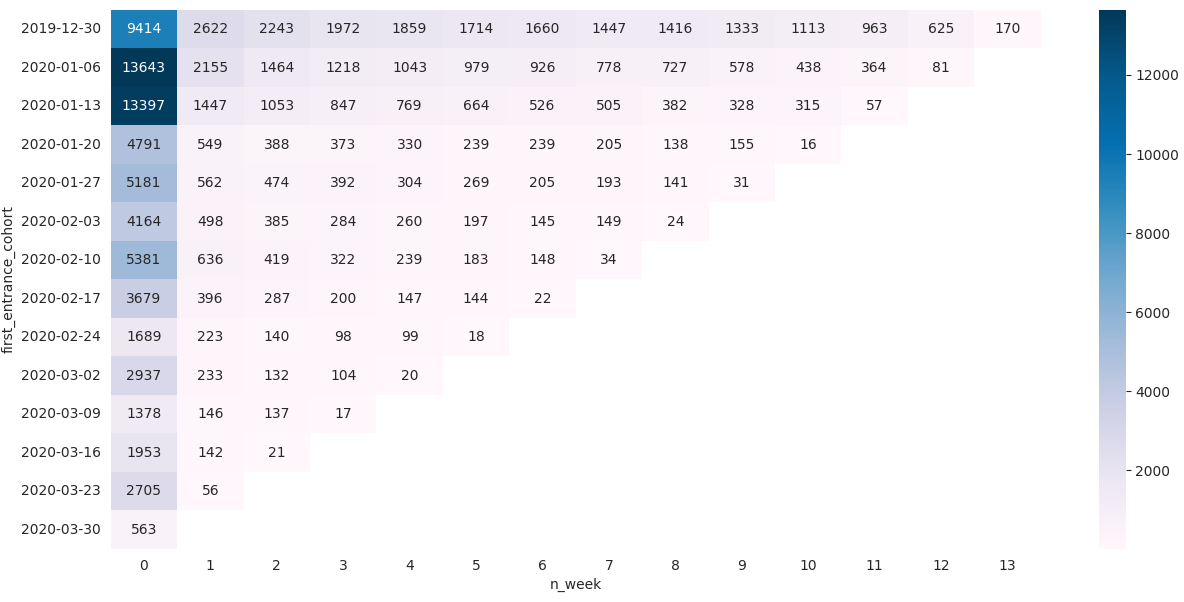

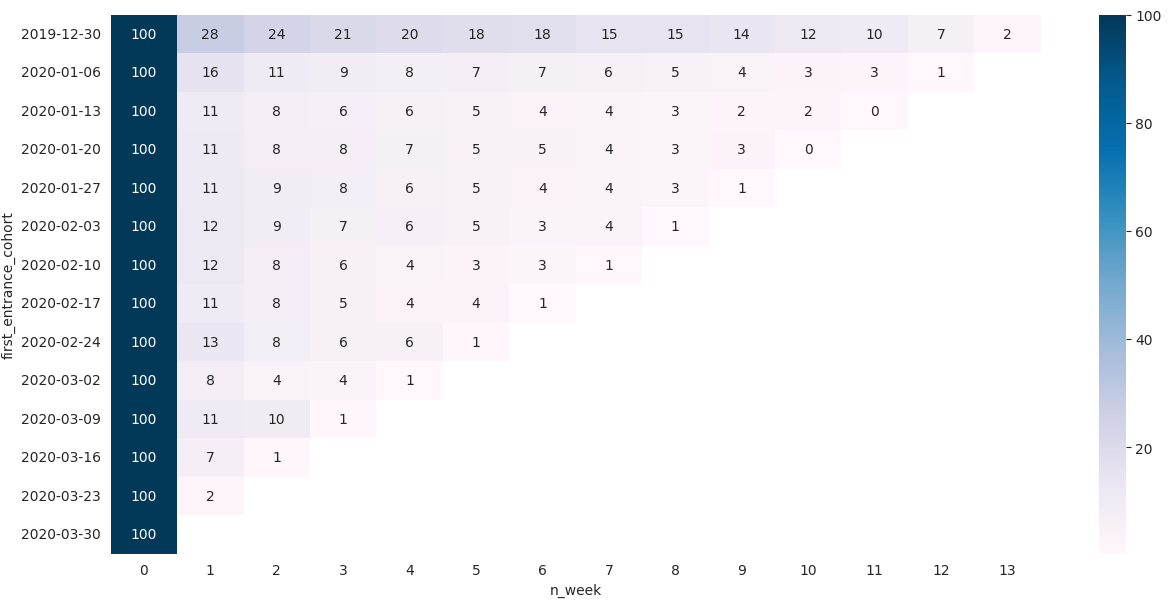

In [44]:
# Визуализируем датафрейм df3 с индексом первого входа по недельной когорте, столбцами: n_week, и значениями: device_id:
viz2 = df3.pivot_table(
            index = 'first_entrance_cohort',
            columns = 'n_week',
            values = 'device_id',
            aggfunc = pd.Series.nunique)

with sns.axes_style('white'):
    f, ax = plt.subplots(figsize = (15, 7))
    ax = sns.heatmap(viz2, annot = True, fmt = '.0f', cmap = 'PuBu');

viz2 = viz2.apply(lambda x: x*100/viz2[0])
with sns.axes_style('white'):
    f, ax = plt.subplots(figsize = (15, 7))
    ax = sns.heatmap(viz2, annot = True, fmt = '.0f', cmap = 'PuBu');

### 8 - вывод:

На графиках выше видно, что первая когорта (2019-12-30) снова является самой активной: начиная с 2-ой по 14-ую недели (n_week: с 1 по 13) - это уже 13 недель подряд (т.е. на 1 неделю больше, чем в когортах с первым посещением в качестве точки отсчёта),  количество активных пользователей данной когорты превышает количество активных пользователей в других когортах. Однако, общая активность пользователей во всех когортах значительно снизилась - в 2-3 раза и более, по сравнению с динамикой активности когорт с первым посещением в качестве точки отсчёта.


Заметка: при построении данных недельных когорт, точкой отсчёта является неделя первой покупки.

### 9: 
##### Расчёт среднего/медианного чека по когортам (недели первой покупки) в каждую неделю с момента первой покупки, указание диапазонов.

/var/folders/66/9b31szhj1zjfx942j3fb6m980000gn/T/ipykernel_18000/258082742.py:2: FutureWarning:

The provided callable <function median at 0x10d303690> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.



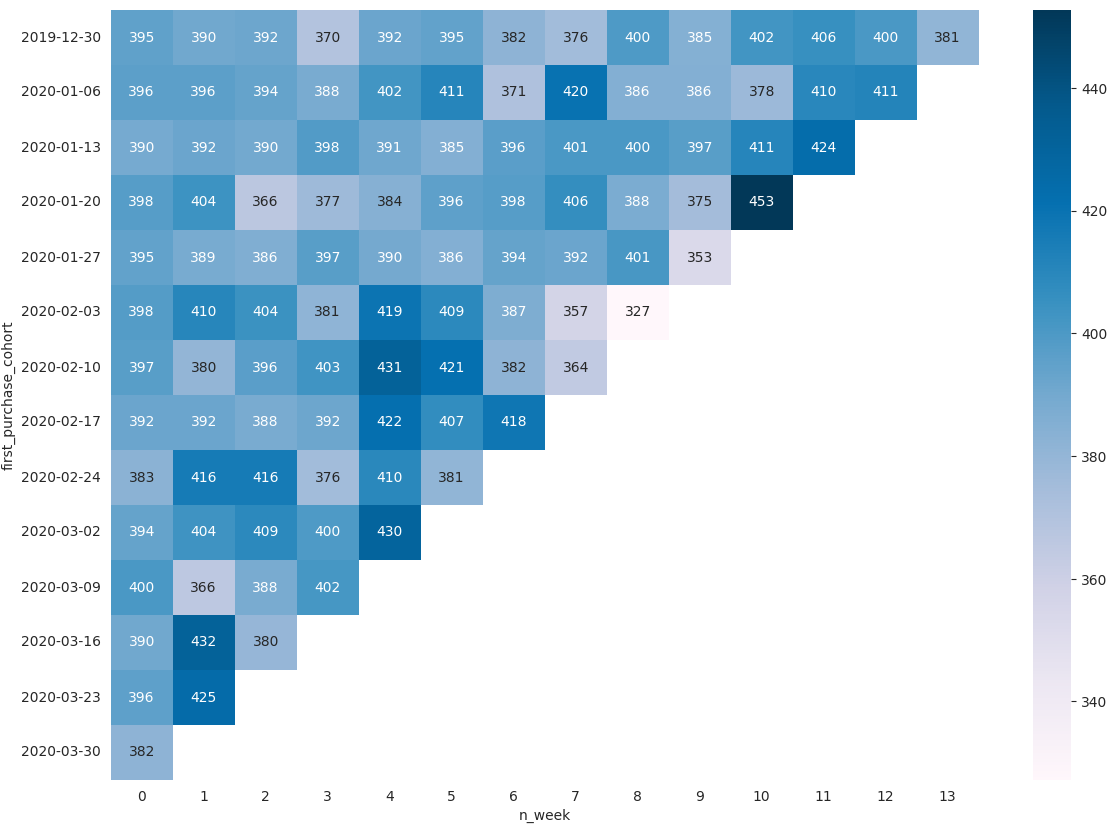

In [45]:
# Визуализируем динамику изменения среднего/медианного чека по когортам (недели первой покупки), используем датафрейм df3:
viz3 = df3.pivot_table(
                index = 'first_purchase_cohort',
                columns = 'n_week',
                values = 'purchase_sum',
                aggfunc = np.median)
with sns.axes_style('white'):
    f, ax = plt.subplots(figsize = (14, 10))
    ax = sns.heatmap(viz3, annot = True, fmt = '.0f', cmap = 'PuBu')

### 9 - вывод:

На графике выше видно как меняется средний/медианный чек по каждой когорте, на протяжении их недельной активности. Например, у первой когорты (2019-12-30), минимальный и максимальный средний чек составляет: 370 и 406, соответственно, а у четвёртой когорты (2020-01-20), минимальный и максимальный средний чек составляет: 366 и 453, соответственно.

/var/folders/66/9b31szhj1zjfx942j3fb6m980000gn/T/ipykernel_18000/334078198.py:2: FutureWarning:

The provided callable <function median at 0x10d303690> is currently using DataFrameGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.



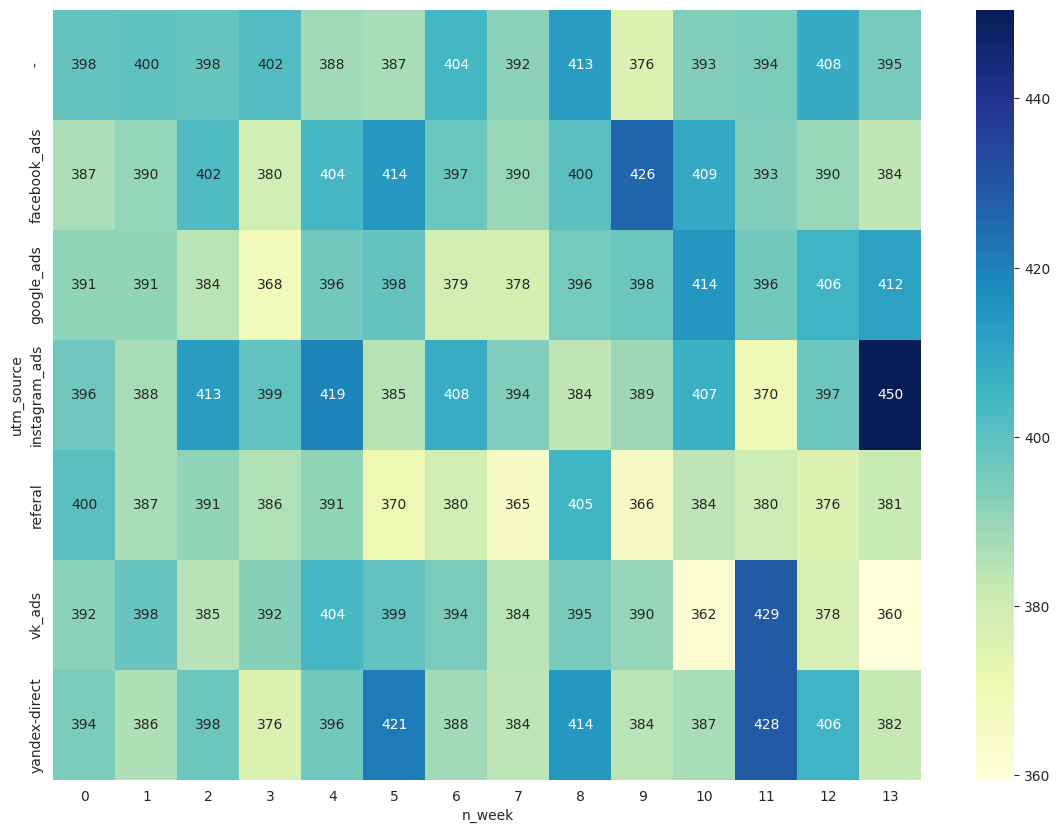

In [46]:
# Визуализируем сравнение медианного чека  с момента первой покупки для всех каналов привлечения.
viz = df.pivot_table(
                        index='utm_source', 
                        columns='n_week', 
                        values='purchase_sum', 
                        aggfunc=np.median)
with sns.axes_style("white"):
    f, ax = plt.subplots(figsize=(14, 10))
    ax = sns.heatmap(viz, annot=True, fmt=".0f", cmap="YlGnBu");

### Основные выводы и рекомендации для маркетологов:


Маркетологам, можно попробовать: 
1. определить точки потенциального роста в предпразничные, праздничные, послепраздничные дни, когда активность резко снижается и проводить дополнительные маркетинговые кампании для удержания высокой активности на более продолжительный период;
2. определить триггеры, ведущие к увеличению динамики открытий приложений у пользователей из группы "Остальные"; 
3. привязать тестовые маркетинговые кампании не к сезонным датам (предпразничные, праздничные, послепразничные дни), а в другим повседневным датам; таким образом, можно протестировать гипотезу, что в сезонные даты активность пользователей выше, чем в обычные дни и перенаправить маркетинговые расходы с сезонных дат на обычные/не сезонные даты;
4. увеличить трафик с каналов привлечения: vk_ads и instagram_ads;
(yandex-direct: 29368, google_ads: 26286, vk_ads: 23189, instagram_ads: 20096, facebook_ads: 13916, referal: 9282)
5. оптимизировать сам процесс покупки, т.е. на шаге добавления товара в корзину, добавить опцию автоматической покупки или другое альтернативное решение, чтобы большая часть зарегистрированных пользователей не отваливалась на этапах покупки (конверсия purchase/tap_basket: 72%);
6. оптимизировать сам процесс регистрации, чтобы большая часть незарегистрированных пользователей не отваливалась на этапе регистрации и также подумать над возможностью добавления опции автоматической покупки или другого альтернативного решения для повышения конверсии на этапе покупки (конверсия purchase/tap_b: 54%): например, с текущего показателя 54% до как минимум 72% - это конверсия в покупку у зарегистрированных пользователей;
7. сократить расходы по худшиму каналу привлечения, такому как yandex-direct (конверсия в покупку: 31.75%), а при наличии маркетингового бюджета, нарастить расходы по лучшим каналам привлечения: реферальная программа (конверсия в покупку: 48.43%); facebook_ads (конверсия в покупку: 41.94%), vk_ads (конверсия в покупку: 41.07%);
8. учитывать ROMI (расчёты рентабельности инвестиций в маркетинг) для каждого канала привлечения и на основе показателей прибыльности каналов формировать рекламный бюджет будущих периодов: например, на следующий период можно выделить больше рекламных расходов на реферальную программу, т.к. ROI по реферальной программе составил 652.22%, что значительно превышает ROMI других каналов - возможно оптимизировать рекламные расходы отдельных кампаний с низким ROMI как google_ads: 22.15%;
9. провести дополнительный анализ сумм покупок в разрезе других критериев (платформ, пола, города пользователя) и извлечь инсайты из проведённого анализа (См. ниже >>> Дополнительный анализ сумм покупок в разрезе критериев...)